# 04 · Classificação e balanceamento
**PP2:** qual algoritmo equilibra precisão e recall na identificação de churn?

Mantemos exatamente o holdout agrupado do notebook 02. No treino, usamos cinco folds de `StratifiedGroupKFold` (semente 43). Escala e reamostragem são ajustadas dentro de cada fold via `imblearn.pipeline.Pipeline`. Comparamos Random Forest, SVM, KNN e Regressão Logística, cada um sem balanceamento, com SMOTENC e com RandomUnderSampler.

SMOTENC é a variante de SMOTE para atributos mistos e preserva as categorias binárias. Contagens e faixas ordinais são tratadas como numéricas: exemplos sintéticos podem ter valores fracionários, uma aproximação do espaço de atributos. StandardScaler e MinMaxScaler são comparados nos métodos sensíveis à escala. RF dispensa escala, mas usamos StandardScaler antes do SMOTENC para a busca de vizinhos.

Seleção: maior F1 médio da classe 1 em CV; desempates por ordem determinística da grade. Primeiro congelamos o vencedor, depois avaliamos todos os candidatos escolhidos por família/estratégia no teste apenas para relatório. Não escolhemos modelo, limiar ou hiperparâmetros pelo teste. O F1 de CV do vencedor está sujeito ao otimismo de seleção; o holdout é a estimativa externa. SVM usa margem (`probability=False`), evitando calibração interna não agrupada. Nenhum score é apresentado como probabilidade calibrada.

In [1]:
from pathlib import Path
import sys, json
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/common.py').exists())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from src.common import *
import matplotlib.pyplot as plt
from IPython.display import display
plt.rcParams.update({'figure.figsize': (10, 5), 'axes.spines.top': False, 'axes.spines.right': False})
df, X, y, groups, tr, te = load_data()
X_train, X_test = X.iloc[tr], X.iloc[te]
y_train, y_test = y.iloc[tr], y.iloc[te]
for directory in ['reports/figuras', 'reports/tabelas', 'reports/dashboards', 'models']:
    (ROOT / directory).mkdir(parents=True, exist_ok=True)


In [2]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay)
from sklearn.base import clone
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from imblearn.under_sampling import RandomUnderSampler
import joblib, importlib.metadata, platform
cv = list(StratifiedGroupKFold(5, shuffle=True, random_state=43).split(X_train, y_train, groups[tr]))
for a,b in cv:
    assert set(groups[tr][a]).isdisjoint(groups[tr][b])
fold_id = np.full(len(X), -1)
for fold, (_, b) in enumerate(cv): fold_id[tr[b]] = fold
pd.DataFrame({'row_id':np.arange(len(X)), 'grupo':groups,
              'conjunto':np.where(np.isin(np.arange(len(X)),tr),'treino','teste'),
              'fold_validacao':fold_id}).to_csv(ROOT/'reports/tabelas/split_manifest.csv',index=False)
models = {
 'Random Forest': (RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=1),
                   {'model__max_depth':[None,10], 'model__min_samples_leaf':[1,3]}),
 'SVM': (SVC(kernel='rbf'), {'model__C':[1,10], 'model__gamma':['scale',.1]}),
 'KNN': (KNeighborsClassifier(), {'model__n_neighbors':[5,15], 'model__weights':['uniform','distance']}),
 'Regressão Logística': (LogisticRegression(max_iter=5000, random_state=SEED), {'model__C':[.1,1,10]})}
scoring = {'f1':'f1', 'precision':'precision', 'recall':'recall', 'roc_auc':'roc_auc', 'ap':'average_precision'}
searches, ranking, all_cv = {}, [], []
for name, (estimator, params) in models.items():
    for strategy in ['Sem balanceamento', 'SMOTENC', 'Undersampling']:
        scale_names = ['standard','minmax'] if name != 'Random Forest' else (['standard'] if strategy=='SMOTENC' else ['none'])
        sampler = ('passthrough' if strategy=='Sem balanceamento' else
                   SMOTENC(categorical_features=list(range(X.shape[1]-3,X.shape[1])), random_state=SEED) if strategy=='SMOTENC' else
                   RandomUnderSampler(random_state=SEED))
        pipe = Pipeline([('prep',preprocessor(X)), ('sampler',sampler), ('model',clone(estimator))])
        grid = {**params, 'prep':[preprocessor(X,s) for s in scale_names]}
        search = GridSearchCV(pipe, grid, scoring=scoring, refit='f1', cv=cv,
                              n_jobs=1, return_train_score=True, error_score='raise')
        search.fit(X_train, y_train)
        key = name+' | '+strategy
        searches[key] = search
        i = search.best_index_
        result = search.cv_results_
        ranking.append({'experimento':key, 'modelo':name, 'balanceamento':strategy,
                        'cv_f1':result['mean_test_f1'][i], 'cv_f1_std':result['std_test_f1'][i],
                        'cv_precision':result['mean_test_precision'][i], 'cv_recall':result['mean_test_recall'][i],
                        'cv_ap':result['mean_test_ap'][i], 'cv_train_f1':result['mean_train_f1'][i],
                        'parametros':str(search.best_params_)})
        all_cv.append(pd.DataFrame(result).assign(experimento=key))
        print(key, round(search.best_score_,4), flush=True)
ranking = pd.DataFrame(ranking).sort_values('cv_f1', ascending=False, kind='stable')
winner = ranking.iloc[0].experimento
final_model = searches[winner].best_estimator_
# Vencedor congelado ANTES de consultar as métricas de teste.
metadata = {'vencedor':winner, 'criterio':'F1 de churn médio em CV agrupada de 5 folds',
            'cv_f1':float(ranking.iloc[0].cv_f1), 'sha256':fingerprint(),
            'n_treino':len(tr), 'n_teste':len(te), 'seed_holdout':42, 'seed_cv':43,
            'features':list(X.columns), 'parametros':str(searches[winner].best_params_),
            'python':platform.python_version(),
            'versoes':{p:importlib.metadata.version(p) for p in ['numpy','pandas','scikit-learn','imbalanced-learn','shap']}}
(ROOT/'reports/tabelas/model_metadata.json').write_text(json.dumps(metadata,indent=2,ensure_ascii=False))
joblib.dump(final_model, ROOT/'models/modelo_final.joblib')
ranking.to_csv(ROOT/'reports/tabelas/comparacao_cv.csv',index=False)
pd.concat(all_cv).to_csv(ROOT/'reports/tabelas/busca_cv_completa.csv',index=False)
display(ranking.drop(columns='parametros').round(4))
print('Modelo final:',winner)

Random Forest | Sem balanceamento 0.8437
Random Forest | SMOTENC 0.8687
Random Forest | Undersampling 0.7424
SVM | Sem balanceamento 0.8097
SVM | SMOTENC 0.8143
SVM | Undersampling 0.7647
KNN | Sem balanceamento 0.8298
KNN | SMOTENC 0.8267
KNN | Undersampling 0.7624
Regressão Logística | Sem balanceamento 0.5406
Regressão Logística | SMOTENC 0.652
Regressão Logística | Undersampling 0.6473
Modelo final: Random Forest | SMOTENC


,experimento,modelo,balanceamento,cv_f1,cv_f1_std,cv_precision,cv_recall,cv_ap,cv_train_f1
1,Random Forest | SMOTENC,Random Forest,SMOTENC,0.8687,0.0310,0.8325,0.9090,0.8918,0.9714
0,Random Forest | Sem balanceamento,Random Forest,Sem balanceamento,0.8437,0.0247,0.8821,0.8100,0.9211,0.9722
6,KNN | Sem balanceamento,KNN,Sem balanceamento,0.8298,0.0160,0.8620,0.8025,0.8993,0.9711
7,KNN | SMOTENC,KNN,SMOTENC,0.8267,0.0123,0.7565,0.9115,0.8470,0.9713
4,SVM | SMOTENC,SVM,SMOTENC,0.8143,0.0277,0.7319,0.9191,0.9158,0.8486
3,SVM | Sem balanceamento,SVM,Sem balanceamento,0.8097,0.0144,0.8733,0.7570,0.9183,0.8504
5,SVM | Undersampling,SVM,Undersampling,0.7647,0.0449,0.6402,0.9544,0.8978,0.7776
8,KNN | Undersampling,KNN,Undersampling,0.7624,0.0237,0.6479,0.9292,0.8187,0.8225
2,Random Forest | Undersampling,Random Forest,Undersampling,0.7424,0.0330,0.6125,0.9444,0.8522,0.8087
10,Regressão Logística | SMOTENC,Regressão Logística,SMOTENC,0.6520,0.0572,0.5189,0.8784,0.7031,0.6490


## Avaliação final e sobreajuste
Treino aparente é medido nos registros originais, sem aumentar o suporte com amostras sintéticas. O teste conserva a distribuição original. Reportamos ambas as classes, médias macro/ponderada e uma baseline majoritária. A queda do treino para CV/teste é um indício de sobreajuste, não um teste estatístico. Os concorrentes no teste são comparações descritivas posteriores à seleção.

,experimento,conjunto,n,acuracia,precisao_churn,recall_churn,f1_churn,roc_auc,average_precision
1,Random Forest | Sem balanceamento,teste,633,0.9668,0.9072,0.88,0.8934,0.9945,0.9707
3,Random Forest | SMOTENC,teste,633,0.9605,0.8378,0.93,0.8815,0.9905,0.9433
5,Random Forest | Undersampling,teste,633,0.9242,0.6781,0.99,0.8049,0.9826,0.8571
7,SVM | Sem balanceamento,teste,633,0.9463,0.8929,0.75,0.8152,0.9818,0.9344
9,SVM | SMOTENC,teste,633,0.9321,0.7176,0.94,0.8139,0.9847,0.9333
11,SVM | Undersampling,teste,633,0.9084,0.6382,0.97,0.7698,0.9839,0.9308
13,KNN | Sem balanceamento,teste,633,0.9431,0.8265,0.81,0.8182,0.9806,0.9141
15,KNN | SMOTENC,teste,633,0.9336,0.7231,0.94,0.8174,0.9735,0.8332
17,KNN | Undersampling,teste,633,0.9052,0.6316,0.96,0.7619,0.9717,0.8055
19,Regressão Logística | Sem balanceamento,teste,633,0.9036,0.8000,0.52,0.6303,0.9405,0.7927


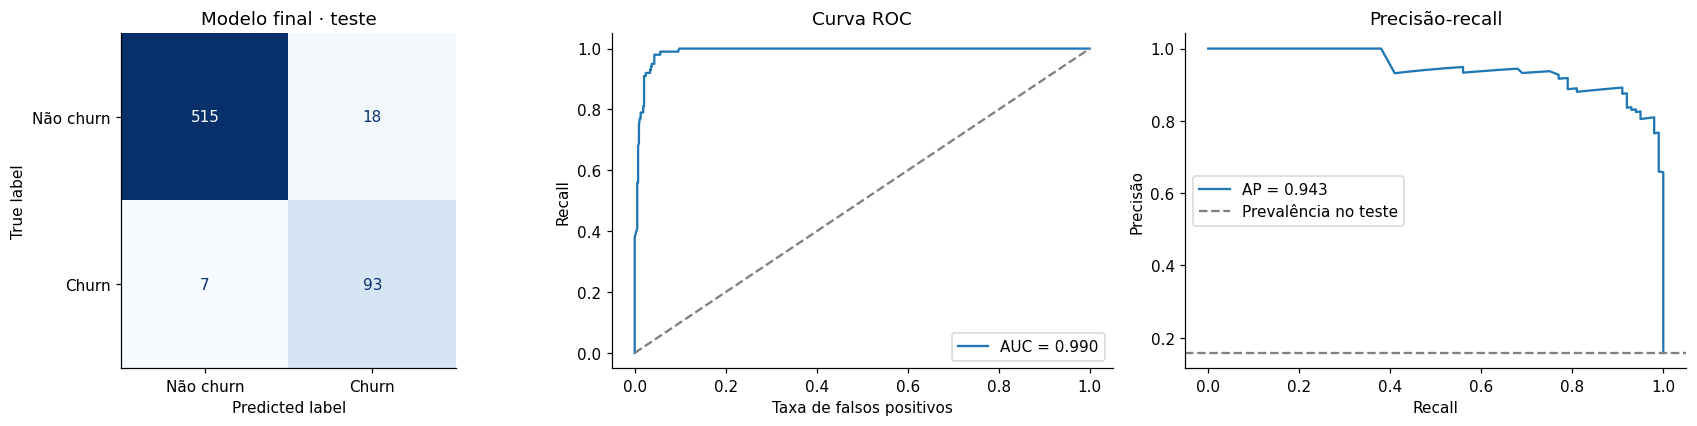

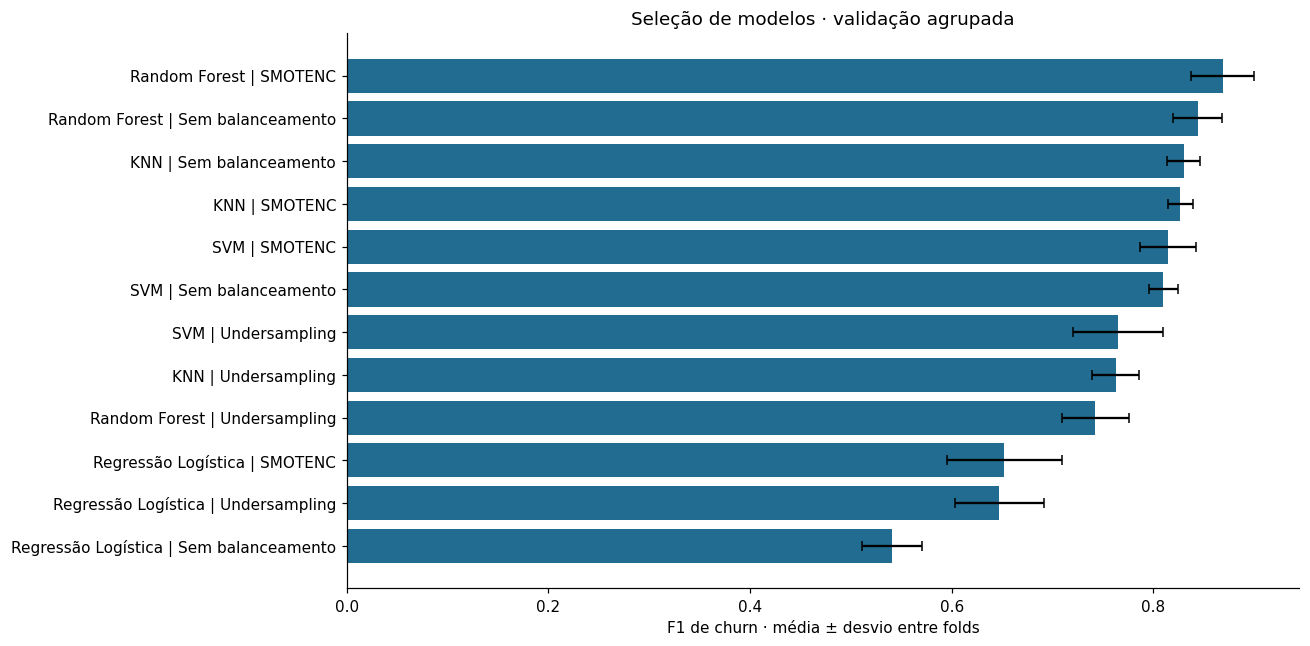

In [3]:
def score_model(model, data):
    return model.decision_function(data) if hasattr(model,'decision_function') else model.predict_proba(data)[:,1]
metrics, reports, predictions = [], [], []
fitted = {key:s.best_estimator_ for key,s in searches.items()}
fitted['Baseline majoritária'] = DummyClassifier(strategy='most_frequent').fit(X_train,y_train)
for key, model in fitted.items():
    for split, data, target in [('treino',X_train,y_train),('teste',X_test,y_test)]:
        pred, score = model.predict(data), score_model(model,data)
        metrics.append({'experimento':key, 'conjunto':split, 'n':len(target),
                        'acuracia':accuracy_score(target,pred), 'precisao_churn':precision_score(target,pred,zero_division=0),
                        'recall_churn':recall_score(target,pred), 'f1_churn':f1_score(target,pred),
                        'roc_auc':roc_auc_score(target,score), 'average_precision':average_precision_score(target,score)})
        report = pd.DataFrame(classification_report(target,pred,output_dict=True,zero_division=0)).T.drop(index='accuracy')
        report.index.name='classe_ou_media'
        reports.append(report.reset_index().assign(experimento=key,conjunto=split))
        predictions.append(pd.DataFrame({'row_id':data.index,'real':target.to_numpy(),'previsto':pred,'score':score,
                                          'experimento':key,'conjunto':split}))
metrics = pd.DataFrame(metrics)
metrics.to_csv(ROOT/'reports/tabelas/metricas_treino_teste.csv',index=False)
pd.concat(reports).to_csv(ROOT/'reports/tabelas/relatorio_classes.csv',index=False)
pd.concat(predictions).to_csv(ROOT/'reports/tabelas/predicoes.csv',index=False)
display(metrics.query("conjunto == 'teste'").round(4))
fig, axes=plt.subplots(1,3,figsize=(16,4))
ConfusionMatrixDisplay.from_estimator(final_model,X_test,y_test,display_labels=['Não churn','Churn'],ax=axes[0],colorbar=False,cmap='Blues')
axes[0].set_title('Modelo final · teste')
score = score_model(final_model,X_test)
fpr,tpr,_ = roc_curve(y_test,score)
precision,recall,_ = precision_recall_curve(y_test,score)
axes[1].plot(fpr,tpr,label=f'AUC = {roc_auc_score(y_test,score):.3f}')
axes[1].plot([0,1],[0,1],'--',color='gray')
axes[1].set(title='Curva ROC',xlabel='Taxa de falsos positivos',ylabel='Recall')
axes[1].legend()
axes[2].plot(recall,precision,label=f'AP = {average_precision_score(y_test,score):.3f}')
axes[2].axhline(y_test.mean(),linestyle='--',color='gray',label='Prevalência no teste')
axes[2].set(title='Precisão-recall',xlabel='Recall',ylabel='Precisão')
axes[2].legend()
savefig(fig,'classificacao_final')
plt.show()
fig,ax=plt.subplots(figsize=(12,6))
order=ranking.experimento.tolist()
positions=np.arange(len(order))
ax.barh(positions,ranking.cv_f1,xerr=ranking.cv_f1_std,color='#226B91',capsize=3)
ax.set_yticks(positions,order)
ax.invert_yaxis()
ax.set(xlabel='F1 de churn · média ± desvio entre folds',title='Seleção de modelos · validação agrupada')
savefig(fig,'classificacao_cv')
plt.show()